### Just compare two models

In [1]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import numpy as np
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers.models import AutoencoderKLFlux2
from diffusers import DDPMScheduler, EulerDiscreteScheduler, FlowMatchEulerDiscreteScheduler
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = "cuda"

In [2]:
text_encoder = CLIPTextModel.from_pretrained("../../stable-diffusion-xl-base-1.0/text_encoder").to("cuda", torch.float32)
tokenizer = CLIPTokenizer.from_pretrained("../../stable-diffusion-xl-base-1.0/tokenizer")
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(device)

diffusion_scheduler = EulerDiscreteScheduler.from_pretrained("../../stable-diffusion-xl-base-1.0/scheduler", timestep_spacing="trailing")
flow_scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained("../../FLUX.2-klein-4B/scheduler", device=device)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [3]:
def encode_text_batch_enc1(text_batch):
    inputs = tokenizer(
        text_batch,
        padding="max_length",
        truncation=True,
        max_length=tokenizer.model_max_length,
        return_tensors="pt"
    ).to("cuda")
    
    with torch.no_grad():
        embed = text_encoder(inputs.input_ids, output_hidden_states=True, return_dict=True)
        text_embeds = embed.pooler_output

    return text_embeds


latents_bn_mean = vae.bn.running_mean.view(1, -1, 1, 1).to(device)
latents_bn_std = torch.sqrt(vae.bn.running_var.view(1, -1, 1, 1) + vae.config.batch_norm_eps).to(device)

def patchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.view(
        batch_size, num_channels_latents, height // 2, 2, width // 2, 2
    )
    latents = latents.permute(0, 1, 3, 5, 2, 4)
    latents = latents.reshape(
        batch_size, num_channels_latents * 4, height // 2, width // 2
    )
    return latents

def unpatchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), 2, 2, height, width
    )
    latents = latents.permute(0, 1, 4, 2, 5, 3)
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), height * 2, width * 2
    )
    return latents

In [4]:
def make_group_norm(channels: int, max_groups: int = 32, eps: float = 1e-6) -> nn.GroupNorm:
    groups = min(max_groups, channels)
    while channels % groups != 0 and groups > 1:
        groups -= 1
    return nn.GroupNorm(groups, channels, eps=eps)


class AttentionBlock(nn.Module):
    def __init__(
        self, 
        channels: int, 
        num_heads: int = 8, 
        head_dim: int = 64
    ):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.attn_dim = num_heads * head_dim
        
        self.norm = make_group_norm(channels)

        self.to_q = nn.Conv2d(channels, self.attn_dim, kernel_size=1, stride=1, padding=0)
        self.to_k = nn.Conv2d(channels, self.attn_dim, kernel_size=1, stride=1, padding=0)
        self.to_v = nn.Conv2d(channels, self.attn_dim, kernel_size=1, stride=1, padding=0)

        self.to_out = nn.Conv2d(self.attn_dim, channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        
        b, c, H, W = x.shape 
        
        h = self.norm(x) 
        
        q = self.to_q(h)
        k = self.to_k(h)
        v = self.to_v(h)

        q = q.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        k = k.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        v = v.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        
        attn_out = F.scaled_dot_product_attention(q, k, v)
 
        attn_out = attn_out.permute(0, 1, 3, 2).reshape(b, self.attn_dim, H, W)

        out = self.to_out(attn_out)
        
        return out + residual


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int = 128, max_period: int = 10000):
        super().__init__()
        self.dim = dim
        self.max_period = max_period

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        timesteps = timesteps.float()

        freqs = torch.exp(
            -torch.log(torch.tensor(float(self.max_period), device=timesteps.device))
            * torch.arange(half, device=timesteps.device, dtype=timesteps.dtype)
            / half
        )
        args = timesteps[:, None] * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


class ConditioningEncoder(nn.Module):
    """
    Fuses timestep and text into a single conditioning vector.
    """
    def __init__(self, time_dim: int = 128, text_dim: int = 768, cond_dim: int = 256):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)

        self.time_proj = nn.Sequential(
            nn.Linear(time_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

    def forward(self, timestep: torch.Tensor, text_embed: torch.Tensor) -> torch.Tensor:
        time_vec = self.time_proj(self.time_embed(timestep))
        text_vec = self.text_proj(text_embed)
        return time_vec + text_vec


class ConditionedResidualBlock(nn.Module):
    """
    SDXL-style residual block:
      GN -> SiLU -> Conv
      + condition (scale/shift)
      GN -> SiLU -> Dropout -> Conv
      + skip connection
    """
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.norm1 = make_group_norm(input_channels)
        self.conv1 = nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1)

        self.cond_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(cond_dim, 2 * output_channels),
        )

        self.norm2 = make_group_norm(output_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1)

        if input_channels != output_channels:
            self.skip = nn.Conv2d(input_channels, output_channels, kernel_size=1, bias=False)
        else:
            self.skip = nn.Identity()

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale_shift = self.cond_proj(cond)
        scale, shift = scale_shift.chunk(2, dim=1)

        h = self.norm2(h)
        h = h * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + residual


class ResAttnStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()
        self.res = ConditionedResidualBlock(
            input_channels=input_channels,
            output_channels=output_channels,
            cond_dim=cond_dim,
            dropout=dropout,
        )
        self.attn = AttentionBlock(output_channels, num_heads=num_heads) if use_attention else nn.Identity()

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = self.res(x, cond)
        x = self.attn(x)
        return x


class DownStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        num_blocks: int = 1,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()

        attn_flags = [use_attention] * num_blocks

        self.blocks = nn.ModuleList()
        for i in range(num_blocks):
            in_ch = input_channels if i == 0 else output_channels
            self.blocks.append(
                ResAttnStage(
                    input_channels=in_ch,
                    output_channels=output_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    use_attention=attn_flags[i],
                    num_heads=num_heads,
                )
            )

        self.downsample = nn.AvgPool2d(2)

    def forward(self, x: torch.Tensor, cond: torch.Tensor):
        for block in self.blocks:
            x = block(x, cond)
        skip = x
        x = self.downsample(x)
        return x, skip


class UpStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        skip_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        num_blocks: int = 1,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()

        attn_flags = [use_attention] * num_blocks

        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        self.blocks = nn.ModuleList()
        for i in range(num_blocks):
            in_ch = (input_channels + skip_channels) if i == 0 else output_channels
            self.blocks.append(
                ResAttnStage(
                    input_channels=in_ch,
                    output_channels=output_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    use_attention=attn_flags[i],
                    num_heads=num_heads,
                )
            )

    def forward(self, x: torch.Tensor, skip: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = self.upsample(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([x, skip], dim=1)

        for block in self.blocks:
            x = block(x, cond)

        return x


class UNet(nn.Module):
    def __init__(
        self,
        sample_channels: int = 32,
        base_channels: int = 256,
        text_dim: int = 768,
        time_dim: int = 512,
        cond_dim: int = 1024,
        dropout: float = 0.01,
        num_heads: int = 16,
    ):
        super().__init__()

        self.conditioning = ConditioningEncoder(
            time_dim=time_dim,
            text_dim=text_dim,
            cond_dim=cond_dim,
        )

        self.in_conv = nn.Conv2d(sample_channels, base_channels, kernel_size=1, padding=0)

        self.down_stages = nn.ModuleList([
            DownStage(
                input_channels=base_channels,
                output_channels=base_channels,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=2,
                use_attention=False,
                num_heads=num_heads,
            ),
            DownStage(
                input_channels=base_channels,
                output_channels=base_channels * 2,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=4,
                use_attention=True,
                num_heads=num_heads,
            ),
        ])

        self.mid_stages = nn.ModuleList([
            ResAttnStage(
                input_channels=base_channels * 2,
                output_channels=base_channels * 2,
                cond_dim=cond_dim,
                dropout=dropout,
                use_attention=True,
                num_heads=num_heads,
            )
            for _ in range(8)
        ])

        self.up_stages = nn.ModuleList([
            UpStage(
                input_channels=base_channels * 2,
                skip_channels=base_channels * 2,
                output_channels=base_channels,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=4,
                use_attention=True,
                num_heads=num_heads,
            ),
            UpStage(
                input_channels=base_channels,
                skip_channels=base_channels,
                output_channels=base_channels,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=2,
                use_attention=False,
                num_heads=num_heads,
            ),
        ])

        self.out_conv = nn.Conv2d(base_channels, sample_channels, kernel_size=1, padding=0)

    def forward(self, sample: torch.Tensor, timestep: torch.Tensor, text_embed: torch.Tensor) -> torch.Tensor:
        cond = self.conditioning(timestep, text_embed)

        x = self.in_conv(sample)

        skips = []
        for down in self.down_stages:
            x, skip = down(x, cond)
            skips.append(skip)

        for mid in self.mid_stages:
            x = mid(x, cond)

        for up in self.up_stages:
            x = up(x, skips.pop(), cond)

        x = self.out_conv(x)
        return x

In [5]:
model_1 = UNet()
model_1 = model_1.to(device)
state_dict = torch.load('../../trained_models/flow_unet_l-1.1.pth', weights_only=True)
model_1.load_state_dict(state_dict)
model_1 = model_1.eval()

model_2 = UNet()
model_2 = model_2.to(device)
state_dict = torch.load('../../trained_models/flow_unet_l_self_flow-2.pth', weights_only=True)
model_2.load_state_dict(state_dict)
model_2 = model_2.eval()

In [7]:
@torch.no_grad()
def sample_with_diffusion(prompt, cfg = 7.0, seed = None, num_samples = 1, steps = 50):
    text_embed = encode_text_batch_enc1([prompt])
    negative_text_embed = torch.zeros_like(text_embed)

    generator = torch.Generator(device=device).manual_seed(seed) if seed is not None else None

    diffusion_scheduler.set_timesteps(steps)
    latents = torch.normal(0, 1, (num_samples, 32, 32, 32), dtype=torch.float32, device="cuda", generator=generator)
    latents = latents * diffusion_scheduler.init_noise_sigma

    diffusion_unet.eval()

    for t in diffusion_scheduler.timesteps:
        latent_model_input = diffusion_scheduler.scale_model_input(latents, t)
        t = t.to(device).view(1)
        predicted_noise = diffusion_unet(sample=latent_model_input, timestep=t, text_embed=text_embed)
        negative_predicted_noise = diffusion_unet(sample=latent_model_input, timestep=t, text_embed=negative_text_embed)
        predicted_noise_cfg = negative_predicted_noise + (predicted_noise - negative_predicted_noise) * cfg
        latents = diffusion_scheduler.step(predicted_noise_cfg, t, latents).prev_sample

    latents = patchify_latents(latents)
    latents = latents * latents_bn_std
    latents = latents + latents_bn_mean
    latents = unpatchify_latents(latents)
    images = (vae.decode(latents).sample + 1.0) / 2.0

    images = images.permute((0, 2, 3, 1)).float().cpu().numpy()
    images = np.clip(images, 0, 1)

    return images


@torch.no_grad()
def sample_with_flow_matching(prompt, cfg = 7.0, seed = None, num_samples = 1, steps = 50, model=None):
    text_embed = encode_text_batch_enc1([prompt])
    negative_text_embed = torch.zeros_like(text_embed)

    generator = torch.Generator(device=device).manual_seed(seed) if seed is not None else None

    flow_scheduler.set_timesteps(steps, mu=1.0)
    latents = torch.normal(0, 1, (num_samples, 32, 32, 32), dtype=torch.float32, device="cuda", generator=generator)

    model.eval()

    for t in flow_scheduler.timesteps:
        latent_model_input = latents
        t = t.to(device).view(1)
        predicted_noise = model(sample=latent_model_input, timestep=t, text_embed=text_embed)
        negative_predicted_noise = model(sample=latent_model_input, timestep=t, text_embed=negative_text_embed)
        predicted_noise_cfg = negative_predicted_noise + (predicted_noise - negative_predicted_noise) * cfg
        latents = flow_scheduler.step(predicted_noise_cfg, t, latents).prev_sample

    latents = patchify_latents(latents)
    latents = latents * latents_bn_std
    latents = latents + latents_bn_mean
    latents = unpatchify_latents(latents)
    images = (vae.decode(latents).sample + 1.0) / 2.0

    images = images.permute((0, 2, 3, 1)).float().cpu().numpy()
    images = np.clip(images, 0, 1)

    return images

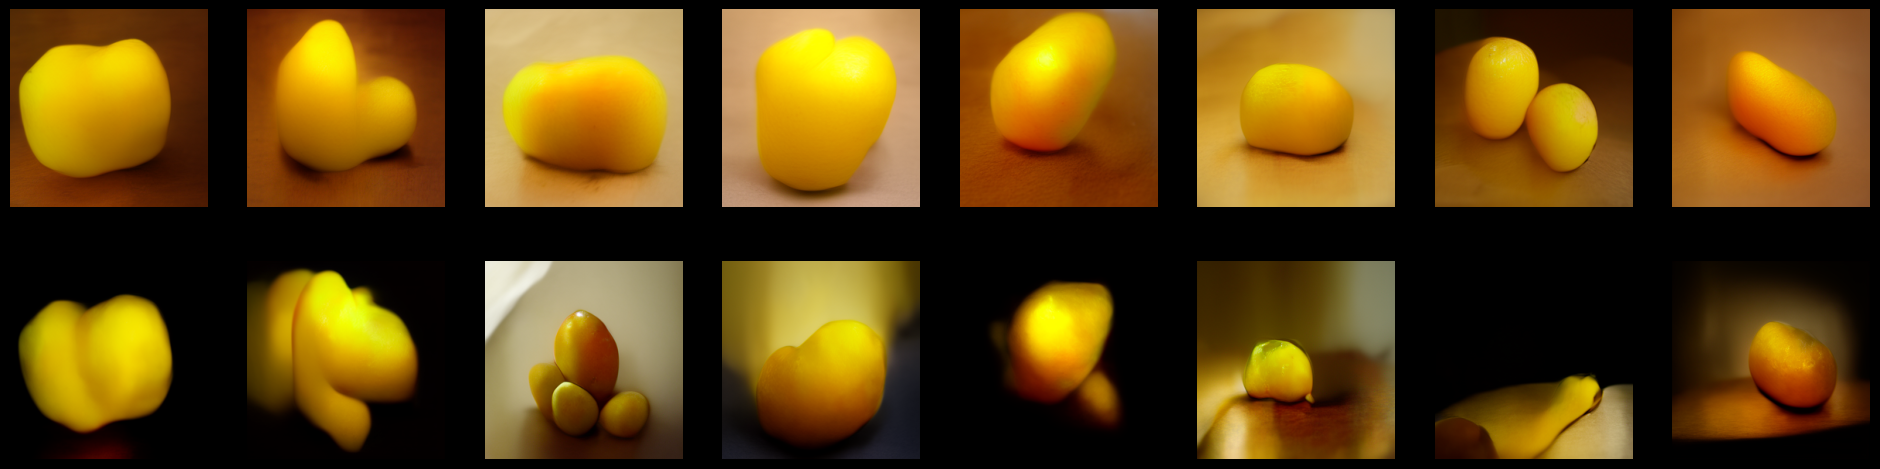

In [10]:
seed = 123
prompt = "A yellow apple on the empty table."
num_samples = 8
images_1 = sample_with_flow_matching(prompt=prompt, seed=seed, num_samples=num_samples, model=model_1)
images_2 = sample_with_flow_matching(prompt=prompt, seed=seed, num_samples=num_samples, model=model_2)

fig, ax = plt.subplots(2, num_samples, figsize=(num_samples * 3, 6))
for i in range(num_samples):
    ax[0, i].imshow(images_1[i])
    ax[0, i].axis("off")
    ax[1, i].imshow(images_2[i])
    ax[1, i].axis("off")


/tmp/ipykernel_48378/282312711.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.2)


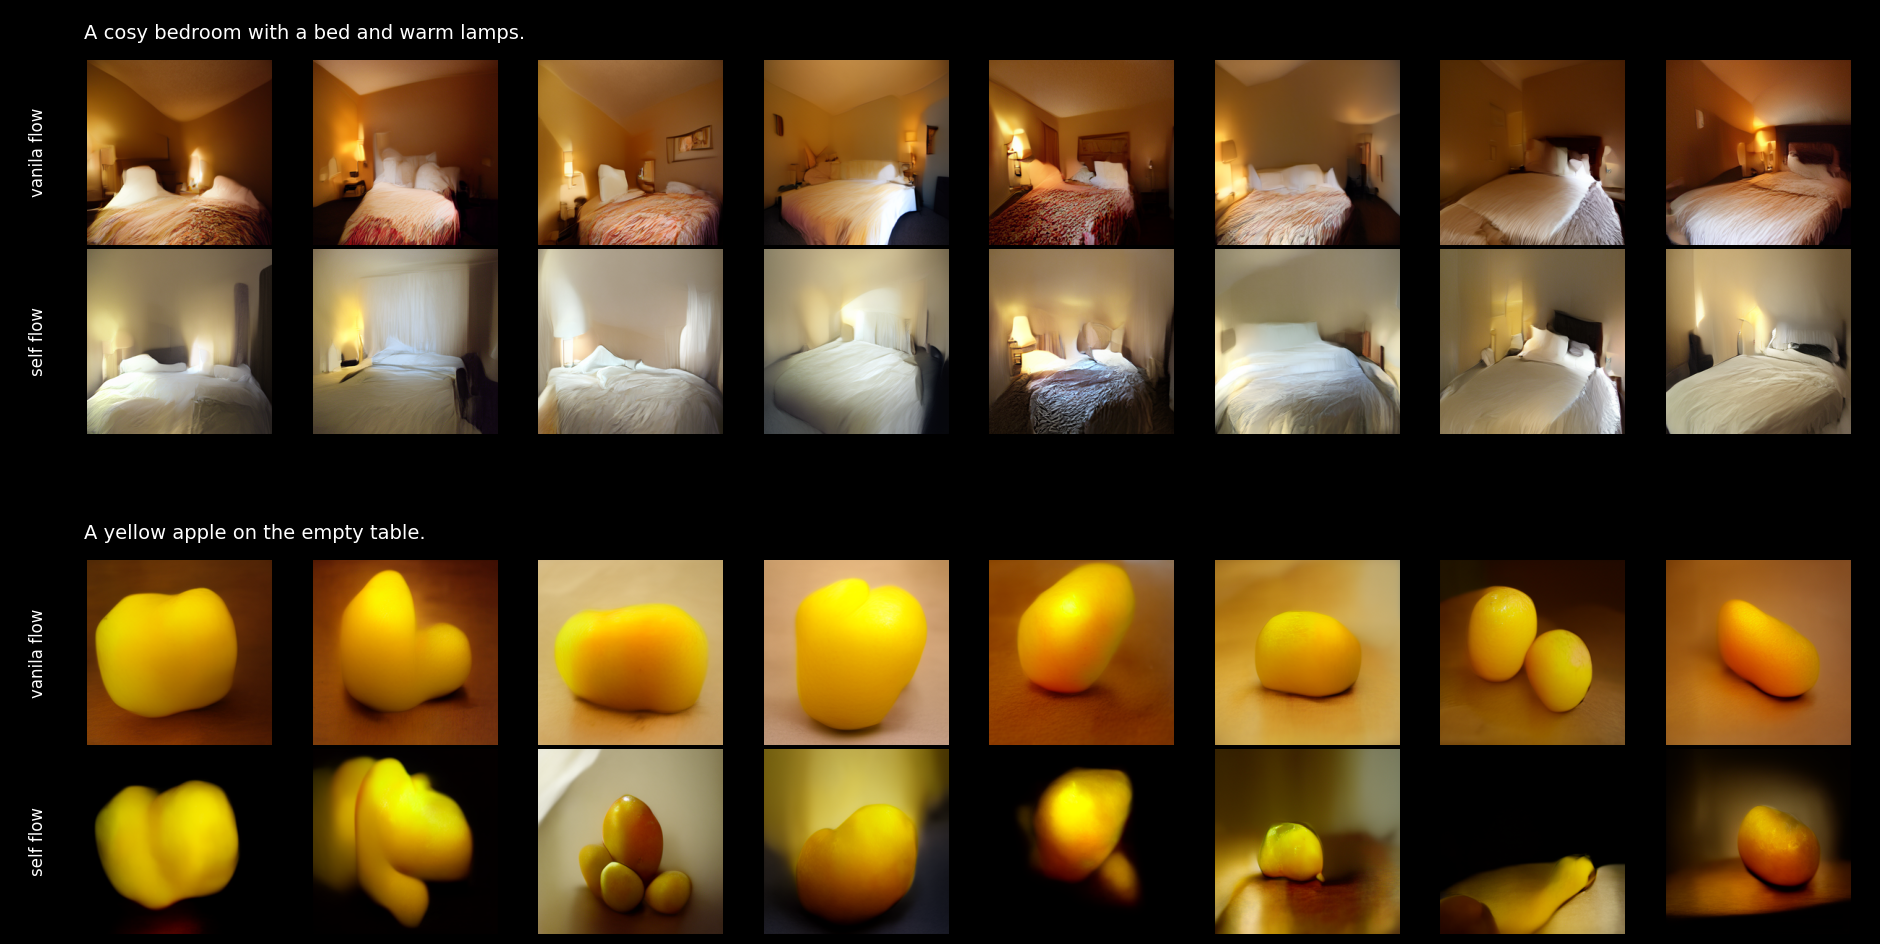

In [13]:
import matplotlib.pyplot as plt

prompts = [
    "A cosy bedroom with a bed and warm lamps.",
    "A yellow apple on the empty table."
]

model_1_name = "vanila flow"
model_2_name = "self flow"

seed = 123
num_samples = 8

fig = plt.figure(figsize=(num_samples * 3, len(prompts) * 6))
outer = fig.add_gridspec(len(prompts), 1, hspace=0.18)

for p, prompt in enumerate(prompts):
    images_1 = sample_with_flow_matching(prompt=prompt, seed=seed, num_samples=num_samples, model=model_1)
    images_2 = sample_with_flow_matching(prompt=prompt, seed=seed, num_samples=num_samples, model=model_2)


    gs = outer[p].subgridspec(
        3, num_samples + 1,
        width_ratios=[0.25] + [1] * num_samples,
        height_ratios=[0.25, 1, 1],
        wspace=0.01,
        hspace=0.03,
    )

    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis("off")
    ax_title.text(0.04, 0.5, prompt, ha="left", va="center", fontsize=14)

    ax_diff_label = fig.add_subplot(gs[1, 0])
    ax_diff_label.axis("off")
    ax_diff_label.text(
        0.5, 0.5, model_1_name,
        rotation=90, ha="center", va="center", fontsize=12
    )

    for i in range(num_samples):
        ax = fig.add_subplot(gs[1, i + 1])
        ax.imshow(images_1[i])
        ax.axis("off")

    ax_flow_label = fig.add_subplot(gs[2, 0])
    ax_flow_label.axis("off")
    ax_flow_label.text(
        0.5, 0.5, model_2_name,
        rotation=90, ha="center", va="center", fontsize=12
    )

    for i in range(num_samples):
        ax = fig.add_subplot(gs[2, i + 1])
        ax.imshow(images_2[i])
        ax.axis("off")

plt.tight_layout(pad=0.2)
plt.show()